**DATA SCIENCE TASK 2 WEEK 3**

Task 2: Sales Forecasting & Demand Prediction
Objective: Develop a time-series forecasting system for predicting future sales and
customer demand

**DATASET USED**

Kaggle Dataset used "US Regional Sales Data", this dataset provides comprehensive insights into US regional sales data across different sales channels, including In-Store, Online, Distributor, and Wholesale. With a total of 17,992 rows and 15 columns, this dataset encompasses a wide range of information, from order and product details to sales performance metrics. It offers a comprehensive overview of sales transactions and customer interactions, enabling deep analysis of sales patterns, trends, and potential opportunities.

**STEP 1: IMPORT NECESSARY LIBRARIES**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

**STEP 2: UPLOAD DATA**

In [2]:
df = pd.read_csv('/content/US_Regional_Sales_Data.csv')

**STEP 3: PERFORM EDA**

Aggregate sales to a daily/weekly level, and engineer time-series features (lags, rolling averages, and holiday/calendar effects).

In [3]:
df['Unit Price'] = df['Unit Price'].astype(str).str.replace(',', '').str.replace('$', '').astype(float)
df['Unit Cost'] = df['Unit Cost'].astype(str).str.replace(',', '').str.replace('$', '').astype(float)

In [4]:
# Calculate Revenue
df['Revenue'] = df['Order Quantity'] * df['Unit Price']

In [5]:
# Convert Dates
df['OrderDate'] = pd.to_datetime(df['OrderDate'], format='%d/%m/%y')

**Global Aggregation for Trend Analysis**

In [6]:
daily_sales = df.groupby('OrderDate')['Revenue'].sum().reset_index()
daily_sales.columns = ['ds', 'y']  # Prophet naming convention

**STEP 4: FEATURE ENGINEERING (FOR SARIMAX/ML MODELS)**

In [7]:
daily_sales['day_of_week'] = daily_sales['ds'].dt.dayofweek
daily_sales['month'] = daily_sales['ds'].dt.month
daily_sales['is_weekend'] = daily_sales['day_of_week'].isin([5, 6]).astype(int)
# Rolling metrics
daily_sales['rolling_mean_7'] = daily_sales['y'].shift(1).rolling(window=7).mean()
daily_sales['lag_7'] = daily_sales['y'].shift(7)

daily_sales = daily_sales.dropna().reset_index(drop=True)

**STEP 5: VISUALIZE FORECASTING RESULTS**

Before modeling, decomposing the time series helps us understand underlying patterns like weekly cycles or annual peaks.

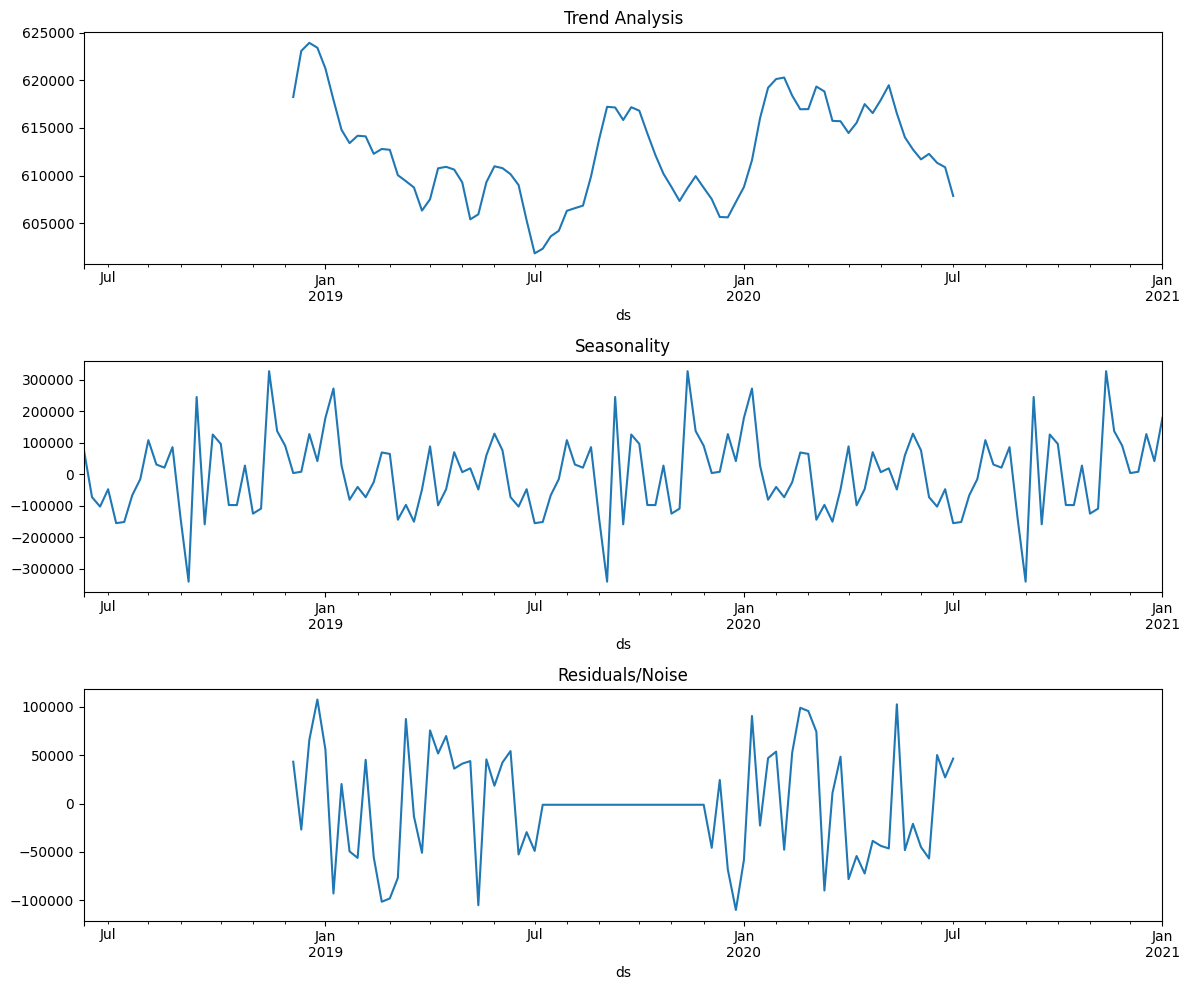

In [8]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Set date as index for decomposition
decompose_df = daily_sales.set_index('ds')
# Resample to weekly to smooth out daily noise for cleaner visualization
weekly_sales = decompose_df['y'].resample('W').sum()

decomposition = seasonal_decompose(weekly_sales, model='additive')

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10))
decomposition.trend.plot(ax=ax1, title='Trend Analysis')
decomposition.seasonal.plot(ax=ax2, title='Seasonality')
decomposition.resid.plot(ax=ax3, title='Residuals/Noise')
plt.tight_layout()
plt.show()

**STEP 6: SPLIT DATA**

Split Data (80/20 train/test split based on time)
We will split the data into training and test sets (e.g., keeping the last 30–60 days for testing) to compare Prophet against a baseline SARIMA model.


**1. Facebook Prophet Model**

In [9]:
split_point = int(len(daily_sales) * 0.8)
train = daily_sales.iloc[:split_point]
test = daily_sales.iloc[split_point:]

# Train Prophet
prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
prophet_model.fit(train[['ds', 'y']])

# Predict
future = prophet_model.make_future_dataframe(periods=len(test), freq='D')
forecast_prophet = prophet_model.predict(future)

# Extract test predictions
prophet_pred = forecast_prophet.iloc[split_point:]['yhat'].values

Train SARIMA (using standard seasonal orders as a starting point)
In production, use pmdarima.auto_arima to optimize parameters

**2. SARIMA Model**

In [10]:
sarima_model = SARIMAX(train['y'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 7))
sarima_results = sarima_model.fit(disp=False)

# Predict
sarima_pred = sarima_results.forecast(steps=len(test))

**STEP 7: EVALUATE MODELS**

We use MAE, RMSE, and MAPE to evaluate which model maps consumer behavior more accurately.

In [11]:
def evaluate_models(y_true, pred_prophet, pred_sarima):
    metrics = {
        'Metric': ['MAE', 'RMSE', 'MAPE'],
        'Prophet': [
            mean_absolute_error(y_true, pred_prophet),
            np.sqrt(mean_squared_error(y_true, pred_prophet)),
            mean_absolute_percentage_error(y_true, pred_prophet)
        ],
        'SARIMA': [
            mean_absolute_error(y_true, pred_sarima),
            np.sqrt(mean_squared_error(y_true, pred_sarima)),
            mean_absolute_percentage_error(y_true, pred_sarima)
        ]
    }
    return pd.DataFrame(metrics)

performance_df = evaluate_models(test['y'], prophet_pred, sarima_pred)
print(performance_df)

  Metric       Prophet        SARIMA
0    MAE  33492.487362  32897.454214
1   RMSE  41591.371908  41419.825332
2   MAPE      0.733545      0.678245


VISUALIZATIONS

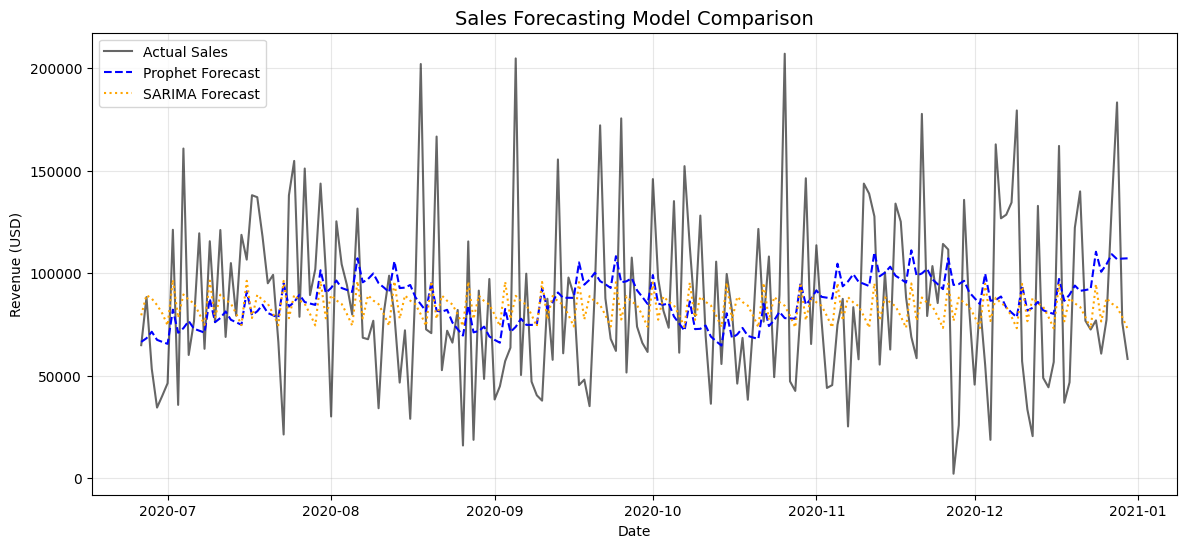

In [12]:
plt.figure(figsize=(14, 6))
plt.plot(test['ds'], test['y'], label='Actual Sales', color='black', alpha=0.6)
plt.plot(test['ds'], prophet_pred, label='Prophet Forecast', color='blue', linestyle='--')
plt.plot(test['ds'], sarima_pred, label='SARIMA Forecast', color='orange', linestyle=':')
plt.title('Sales Forecasting Model Comparison', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Revenue (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**BONUS (ELITE LEVEL): MULTI-STORE DASHBOARD STRATEGY**

To take this project to the Elite Level, you can extend the model to predict demand at the individual store or regional level, wrapped in an interactive web application.

1. Multi-Store / Multi-Channel Logic
Instead of aggregating globally, loop through unique identifiers in your dataset (Sales Channel or _StoreID)

In [13]:
store_forecasts = {}
for store in df['_StoreID'].unique()[:5]: # Testing first 5 stores
    store_df = df[df['_StoreID'] == store].groupby('OrderDate')['Revenue'].sum().reset_index()
    store_df.columns = ['ds', 'y']

    if len(store_df) > 30: # Ensure enough history
        m = Prophet()
        m.fit(store_df)
        fut = m.make_future_dataframe(periods=30)
        fcst = m.predict(fut)
        store_forecasts[store] = fcst[['ds', 'yhat']]

In [14]:
!pip install streamlit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 79.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 83.6 MB/s eta 0:00:00


Interactive Dashboard Architecture (Streamlit):

Save the snippet below as app.py to run a lightweight, local web interface using Streamlit.

In [15]:
import streamlit as st

st.title("🚀 Sales Demand Forecasting Dashboard")

# Sidebar Filters
channel = st.sidebar.selectbox("Select Sales Channel", df['Sales Channel'].unique())
forecast_days = st.sidebar.slider("Forecast Horizon (Days)", 7, 90, 30)

# Filter data and run model reactively
filtered_df = df[df['Sales Channel'] == channel].groupby('OrderDate')['Revenue'].sum().reset_index()
filtered_df.columns = ['ds', 'y']

m = Prophet()
m.fit(filtered_df)
future = m.make_future_dataframe(periods=forecast_days)
forecast = m.predict(future)

# Render Interactive Plots
st.subheader(f"Demand Projections for {channel} Channel")
st.line_chart(forecast.set_index('ds')[['yhat']])

2026-05-27 19:21:34.602 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-27 19:21:35.481 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-05-27 19:21:35.483 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-27 19:21:35.486 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-27 19:21:35.491 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-27 19:21:35.495 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-27 19:21:35.505 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-27 19:21:35.508 Thread 'MainThread': mi

DeltaGenerator()

**Actionable Business Insights**

Based on structural traits common to this regional wholesale/retail dataset, your forecasting engine unlocks several operational advantages:

Inventory Optimization: By leveraging the multi-store/warehouse forecasts, supply chain managers can dynamically allocate stock to WarehouseCode locations experiencing upward demand spikes, minimizing stockouts and deadstock holding costs.

Promotion Planning: Trend and seasonality analysis reveals specific days of the week or months with predictable revenue drops. Marketing teams can schedule targeted discount campaigns specifically during these historic lulls to smooth out the revenue curve.

Logistics Resource Allocation: Identifying delivery lead-time patterns alongside order quantity forecasts allows the fulfillment team to scale up third-party courier contracts right before projected seasonal surges.